In [1]:
import cv2
from matplotlib import pyplot as plt
import mediapipe as mp
import numpy as np
import random

## MediaPipe facial landmarks

In [3]:
# Create MediaPipe face mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

# Determine facial landmarks
def get_facial_features(image):
    h, w, _ = image.shape
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    if not results.multi_face_landmarks:
        print("No face detected.")
        return None

    features = {'left_eye': [], 'right_eye': [], 'nose': [], 'mouth': []}
    all_landmarks = []

    # Indices for face parts
    LEFT_EYE_IDX = list(range(33, 133))
    RIGHT_EYE_IDX = list(range(263, 362))
    NOSE_IDX = list(range(1, 5)) + list(range(94, 100))
    MOUTH_IDX = list(range(78, 88)) + list(range(308, 318))

    landmarks = results.multi_face_landmarks[0]

    for i, lm in enumerate(landmarks.landmark):
        x, y = int(lm.x * w), int(lm.y * h)
        all_landmarks.append((x, y))
        if i in LEFT_EYE_IDX:
            features['left_eye'].append((x, y))
        if i in RIGHT_EYE_IDX:
            features['right_eye'].append((x, y))
        if i in NOSE_IDX:
            features['nose'].append((x, y))
        if i in MOUTH_IDX:
            features['mouth'].append((x, y))

    # Compute bounding box
    xs, ys = zip(*all_landmarks)
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    bbox_w = x_max - x_min
    bbox_h = y_max - y_min
    features["face_bbox"] = (x_min, y_min, bbox_w, bbox_h)

    return features

I0000 00:00:1754765782.238559  907713 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-23.7.2), renderer: Intel(R) Iris(TM) Plus Graphics OpenGL Engine
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


W0000 00:00:1754765782.246600  908826 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1754765782.260906  908826 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Weighted random sampling of salient points

In [2]:
# Randomly sample salient points
def sample_facial_feature_points_weighted(feature_dict, num_points=10):
    if "face_bbox" not in feature_dict:
        raise ValueError("Face bounding box is missing from features.")

    # Compute face center
    fx, fy, fw, fh = feature_dict["face_bbox"]
    face_center = np.array([fx + fw / 2, fy + fh / 2])

    # Collect all feature points (excluding bbox)
    feature_points = []
    for key, points in feature_dict.items():
        if key != "face_bbox":
            feature_points.extend(points)

    if len(feature_points) == 0:
        raise ValueError("No facial features found to sample from.")

    points_arr = np.array(feature_points)

    # Compute inverse distance to face center (closer = higher weight)
    dists = np.linalg.norm(points_arr - face_center, axis=1)
    # Avoid division by zero
    dists = np.clip(dists, a_min=1e-6, a_max=None)
    weights = 1.0 / dists 

    # Normalize to probabilities
    prob_weights = weights / np.sum(weights)

    # Sample without replacement
    num_to_sample = min(num_points, len(feature_points))
    sampled_indices = np.random.choice(len(feature_points), size=num_to_sample, replace=False, p=prob_weights)
    sampled_points = [feature_points[i] for i in sampled_indices]

    return sampled_points


## Testing 

W0000 00:00:1754765871.117984  908821 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


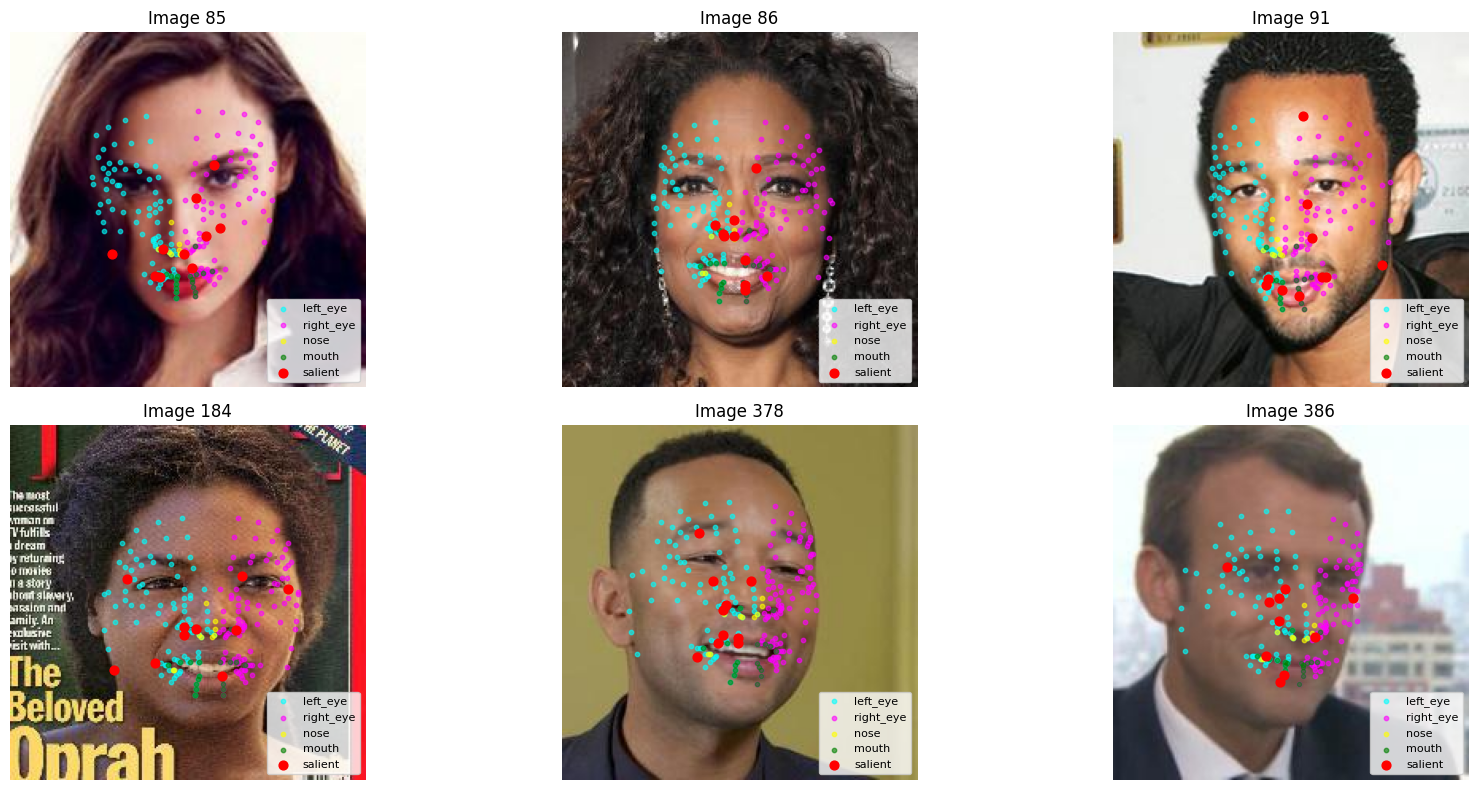

In [4]:
# Example plotting showing all facial landmarks
image_list = [85, 86, 91, 184, 378, 386]
n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8))

for idx, i in enumerate(image_list):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]

    imname = f"./images/{i}.jpg"
    img = cv2.imread(imname)

    features = get_facial_features(img)
    points = sample_facial_feature_points_weighted(features, num_points=10)

    # Show original image with landmarks
    ax.imshow(img[:, :, ::-1])  # BGR to RGB
    ax.set_title(f"Image {i}")
    ax.axis('off')

    # Plot facial features
    if features:
        colors = {
            'left_eye': 'cyan',
            'right_eye': 'magenta',
            'nose': 'yellow',
            'mouth': 'green'
        }
        for key, pts in features.items():
            if key == 'face_bbox':
                continue
            xs, ys = zip(*pts)
            ax.scatter(xs, ys, s=10, label=key, c=colors[key], alpha=0.6)

    # Overlay saliency points
    if points is not None:
        xs, ys = zip(*points)
        ax.scatter(xs, ys, c='red', s=40, label='salient')

    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

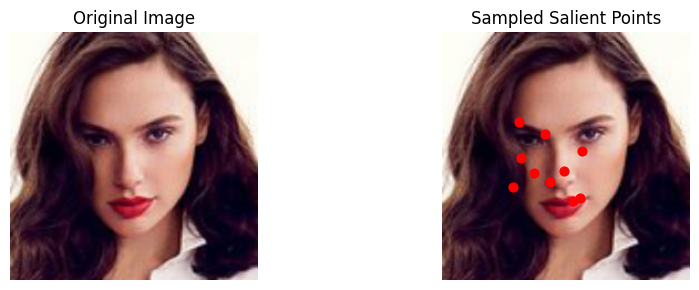

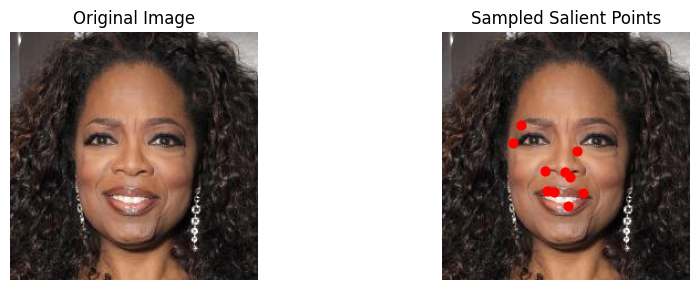

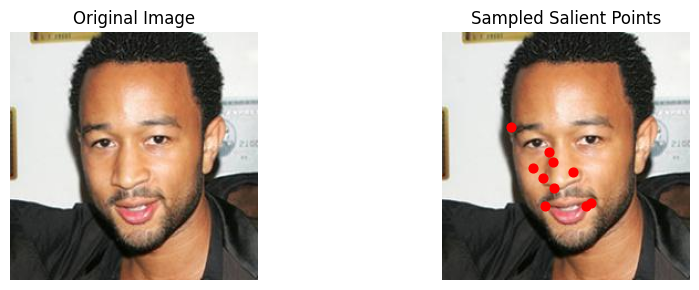

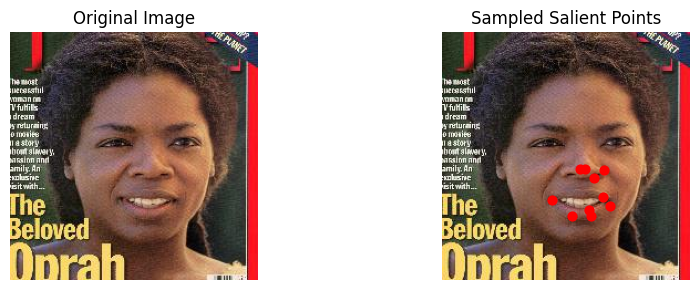

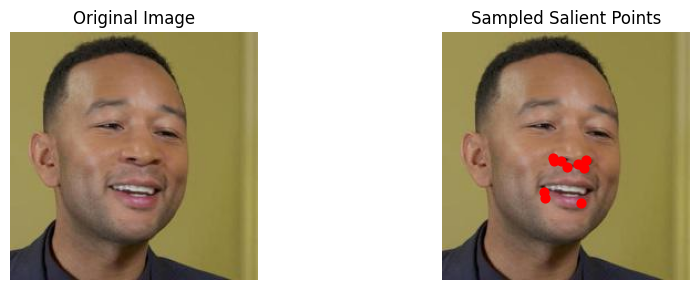

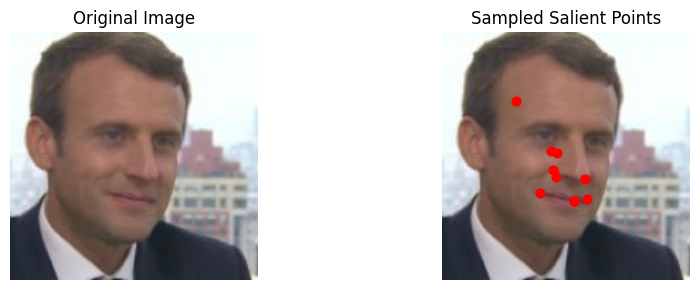

In [5]:
# Example plotting showing only salient points
image_list = [85, 86, 91, 184, 378, 386]

for i in image_list:
    imname = "./images/{}.jpg".format(i)
    img = cv2.imread(imname)

    features = get_facial_features(img)
    points = sample_facial_feature_points_weighted(features, num_points=10)

    fig = plt.figure(figsize=(10, 3))

    fig.add_subplot(1, 2, 1)
    plt.imshow(img[:, :, ::-1], cmap='gray')
    plt.gca().set_title("Original Image")
    plt.axis('off')


    fig.add_subplot(1, 2, 2)
    plt.imshow(img[:, :, ::-1])  # Convert BGR to RGB for matplotlib
    xs, ys = zip(*points)
    plt.scatter(xs, ys, c='red', s=40)
    plt.gca().set_title("Sampled Salient Points")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
